In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical



In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)



Training set shape: (60000, 28, 28, 1)
Testing set shape: (10000, 28, 28, 1)


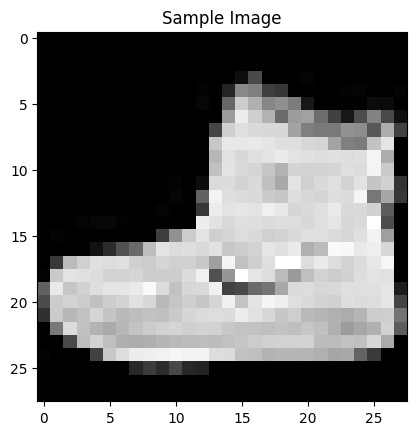

In [4]:
plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title("Sample Image")
plt.show()



In [5]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])



In [6]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)



Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8465 - loss: 0.4346 - val_accuracy: 0.8853 - val_loss: 0.3230
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8960 - loss: 0.2889 - val_accuracy: 0.8924 - val_loss: 0.2944
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9109 - loss: 0.2432 - val_accuracy: 0.9018 - val_loss: 0.2754
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9222 - loss: 0.2110 - val_accuracy: 0.9115 - val_loss: 0.2426
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9329 - loss: 0.1841 - val_accuracy: 0.9122 - val_loss: 0.2456
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9395 - loss: 0.1653 - val_accuracy: 0.9136 - val_loss: 0.2470
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9478 - loss: 0.1435 - val_accuracy: 0.9160 - val_loss: 0.2429
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9532 - loss: 0.1284 - 

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy:", test_accuracy)

predictions = model.predict(x_test[:5])

for i in range(5):
    pred_label = np.argmax(predictions[i])
    true_label = np.argmax(y_test[i])
    print(f"Sample {i+1}: Predicted={pred_label} Actual={true_label}")



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9064 - loss: 0.3082
Test accuracy: 0.9064000248908997
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
Sample 1: Predicted=9 Actual=9
Sample 2: Predicted=2 Actual=2
Sample 3: Predicted=1 Actual=1
Sample 4: Predicted=1 Actual=1
Sample 5: Predicted=6 Actual=6


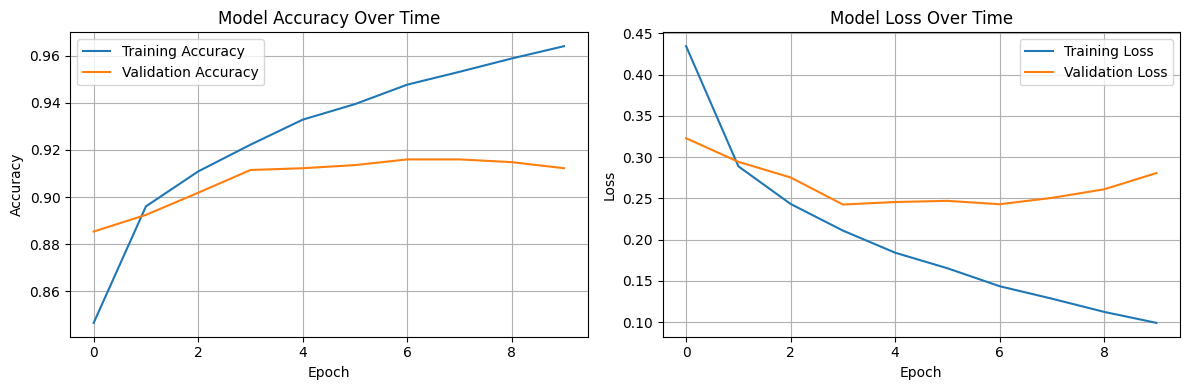

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()